In [4]:
# Импорты и загрузка данных
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if '../../src' not in sys.path:
    sys.path.append('../../src')
from database import load_corrosion_data_new as load_data
from analysis import AdvancedCorrosionAnalyzer


In [6]:
# Настройки
sns.set(style='whitegrid')
TARGET = 'worst_corrosion_rate_mm_per_year'

# Загрузка
DF_loaded = load_data()
assert TARGET in DF_loaded.columns, 'В данных отсутствует corrosion_rate_mm_per_year'

print(f"Данные: {len(DF_loaded):,} строк, {len(DF_loaded.columns)} колонок")
print('Колонки:')
print(sorted(DF_loaded.columns.tolist()))

Данные: 141,945 строк, 47 колонок
Колонки:
['ammonia_content', 'avg_corrosion_rate_mm_per_year', 'chloride_aggressiveness', 'chlorine_content', 'co2_content', 'component_type_id', 'component_type_name', 'contour', 'corrosion_aggressiveness_index', 'corrosion_inhibitor_content', 'corrosion_protection_index', 'cross_sectional_area', 'diameter_category', 'diameter_to_thickness_ratio', 'equipment', 'equipment_age_years', 'h2s_aggressiveness_index', 'h2s_content', 'h2s_water_ratio', 'hydrochloric_acid_content', 'inner_diameter', 'installation', 'material_code', 'material_resistance_score', 'material_type', 'measurement_date', 'measurement_points_in_section', 'min_corrosion_rate_mm_per_year', 'nominal_thickness_mmc', 'operating_pressure', 'operating_temperature', 'outer_diameter', 'oxygen_content', 'pitting_corrosion_index', 'section_number', 'stress_corrosion_index', 'thickness_category', 'tmin_mmc', 'total_acidity_index', 'total_acids', 'total_chlorine_compounds', 'total_sulfur_compounds',

In [39]:
# Фильтрация по нескольким установкам
INSTALLATION_FILTER = ['КК']
DF = DF_loaded[DF_loaded['installation'].isin(INSTALLATION_FILTER)]

print(f"После фильтрации по {INSTALLATION_FILTER}: {len(DF):,} строк")


После фильтрации по ['КК']: 51,019 строк


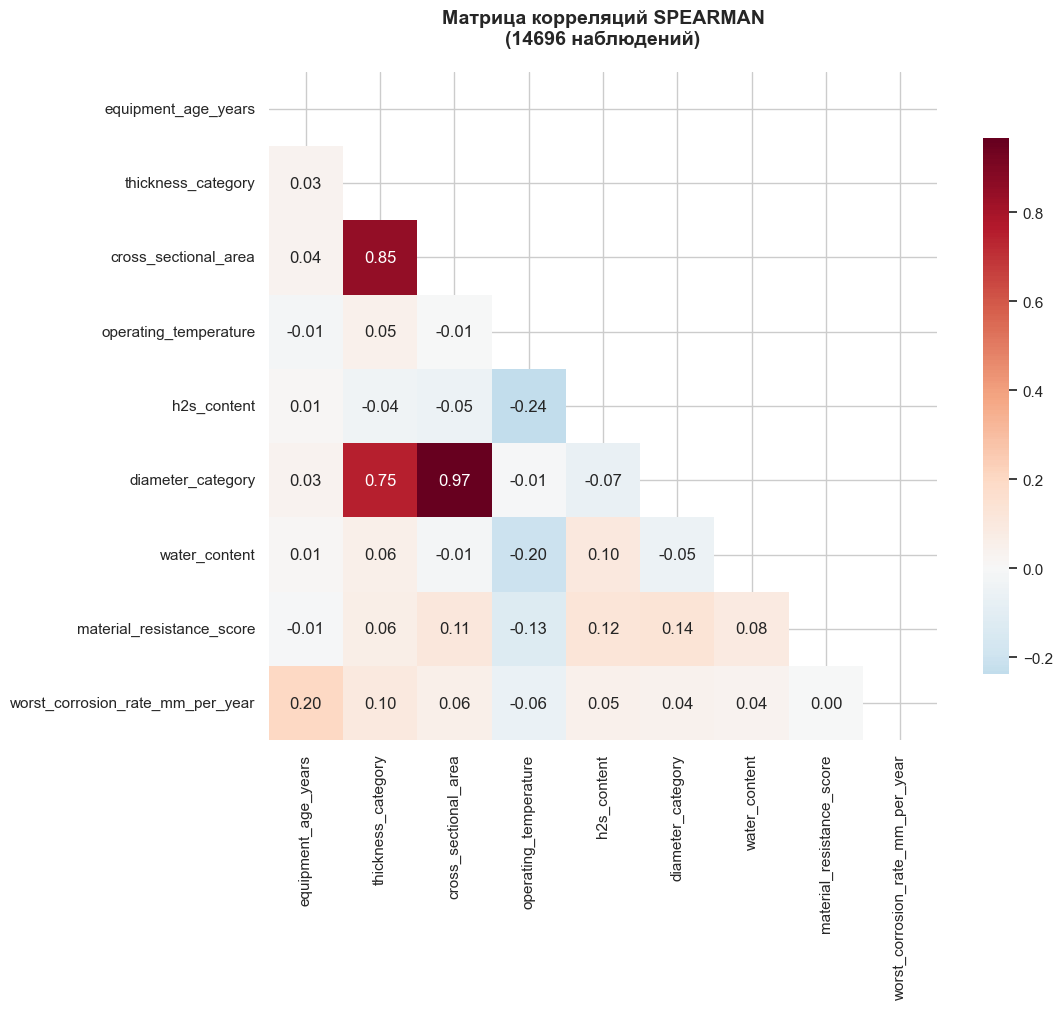

ТОП-8 ПРИЗНАКОВ ПО КОРРЕЛЯЦИИ SPEARMAN

📈 СТАТИСТИЧЕСКИ ЗНАЧИМЫЕ (p < 0.05):
  equipment_age_years            | r =   0.197 *** 🡅
  thickness_category             | r =   0.096 *** 🡅
  cross_sectional_area           | r =   0.063 *** 🡅
  operating_temperature          | r =  -0.061 *** 🡇
  h2s_content                    | r =   0.047 *** 🡅
  diameter_category              | r =   0.044 *** 🡅
  water_content                  | r =   0.036 *** 🡅

📊 Статистика:
   Всего значимых корреляций: 7
   Максимальная корреляция: 0.197
   Минимальная корреляция: 0.001


In [41]:
# 1. Инициализация с любыми данными
analyzer = AdvancedCorrosionAnalyzer(DF)

# 2. Установка целевой переменной
analyzer.set_target('worst_corrosion_rate_mm_per_year')

# 3. Анализ корреляций для конкретных колонок
features_to_analyze = ['h2s_content', 'water_content', 'operating_temperature', 
                      'material_resistance_score', 'equipment_age_years','cross_sectional_area','thickness_category','diameter_category']

correlations = analyzer.analyze_correlations(
    feature_columns=features_to_analyze,
    method='spearman',
    top_k=15,
    plot_matrix=True
)


🔬 Тестируем набор: new
   Признаки: ['thickness_category', 'material_resistance_score', 'operating_pressure', 'operating_temperature', 'equipment_age_years', 'component_type_id', 'corrosion_protection_index', 'stress_corrosion_index']
📊 РЕЗУЛЬТАТЫ МОДЕЛЕЙ
   ridge           | R² =  0.0997 | MAE =  0.0429 | RMSE =  0.0771
   random_forest   | R² =  0.3344 | MAE =  0.0347 | RMSE =  0.0663

🎯 ЛУЧШАЯ МОДЕЛЬ: random_forest (R² = 0.3344)

🔬 Тестируем набор: old
   Признаки: ['h2s_content', 'h2s_water_ratio', 'h2s_aggressiveness_index', 'material_resistance_score', 'wall_thickness', 'equipment_age_years', 'component_type_id', 'corrosion_protection_index', 'stress_corrosion_index']
📊 РЕЗУЛЬТАТЫ МОДЕЛЕЙ
   ridge           | R² =  0.1155 | MAE =  0.0478 | RMSE =  0.0873
   random_forest   | R² =  0.3024 | MAE =  0.0388 | RMSE =  0.0775

🎯 ЛУЧШАЯ МОДЕЛЬ: random_forest (R² = 0.3024)

🔬 Тестируем набор: new2
   Признаки: ['h2s_content', 'material_resistance_score', 'thickness_category', 'equipment

<Figure size 1200x600 with 0 Axes>

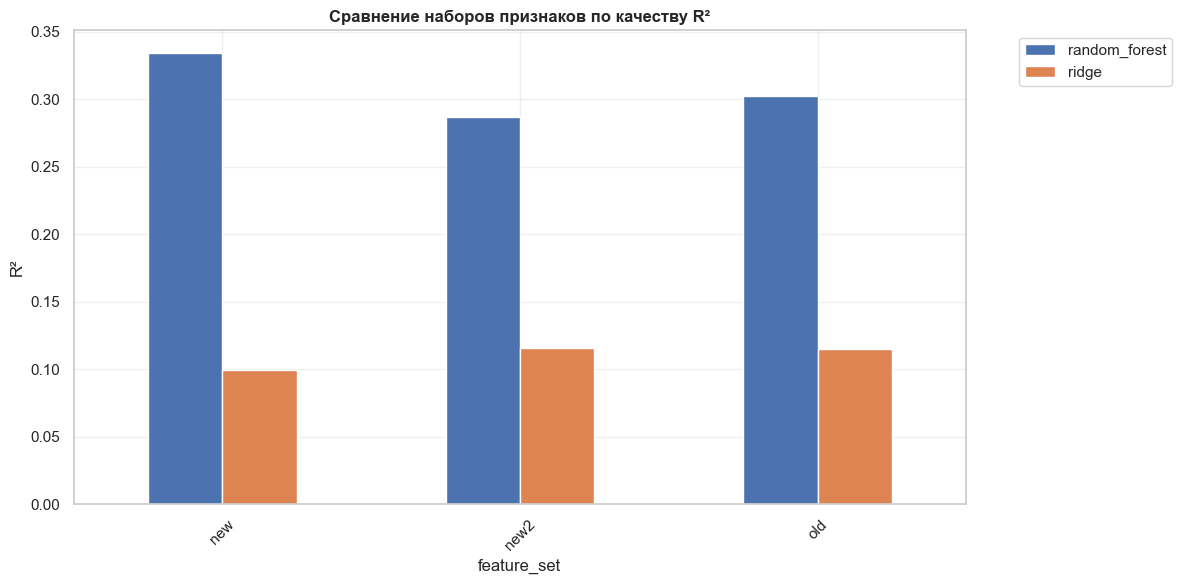

In [47]:
# 5. Сравнение разных наборов признаков
feature_sets = {

    'new': ['thickness_category','material_resistance_score','operating_pressure','operating_temperature','equipment_age_years','component_type_id','corrosion_protection_index','stress_corrosion_index'],
    'old': ['h2s_content', 'h2s_water_ratio','h2s_aggressiveness_index', 'material_resistance_score', 'wall_thickness', 'equipment_age_years','component_type_id','corrosion_protection_index','stress_corrosion_index'],
    'new2': ['h2s_content', 'h2s_water_ratio','h2s_aggressiveness_index', 'material_resistance_score', 'thickness_category', 'equipment_age_years','component_type_id','corrosion_protection_index','stress_corrosion_index'],


}

comparison = analyzer.compare_feature_sets(feature_sets)